In [57]:
import numpy as np
import glob
import scipy as sc
import matplotlib.pyplot as plt
from scipy.special import erfc
from fit_functions import R_sq, EMG, EMG_mirrored, EMGsTailFront, make_constrained_EMG, make_constrained_EMG_mirrored, make_constrained_EMGsTailFront, make_sigma_constrained_EMG, make_sigma_constrained_EMG_mirrored, make_sigma_constrained_EMGsTailFront


**Calibration :**
all masses in g, all areas in a.u. all concentrations in wt% (mass pure solute / total mass)

In [58]:
path = 'data/'
FALD = {
    'name': 'Formaldehyde',
    'stock_c': 37,  # wt% in stock solution
    'water': np.array([0.8533, 0.8868, 0.7250, 0.5555, 1.0525]),
    'stock': np.array([0.4061, 0.2224, 0.4548, 0.6975, 0.1297]),
    'areas': np.array([3277991, 1975810, 3911989, 5744917, 1078320]),
    'p0': (2e5, 644, 3.3, 0.31),
    'hs': [], 'mus': [], 'sigmas': [], 'taus': [], 'fits': [],
    'files': ['CAL-FALD-1.txt', 'CAL-FALD-2.txt', 'CAL-FALD-3.txt', 'CAL-FALD-4.txt', 'CAL-FALD-5.txt'],
    'color': 'C9'
}
FA = {
    'name': 'Formic Acid',
    'stock_c': 100,  # wt% in stock solution
    'water': np.array([0.9708, 0.9620, 0.9157, 0.9194, 0.9276, 1.1981]),
    'stock': np.array([0.0410, 0.0758, 0.2071, 0.4549, 0.1422, 0.0191]),
    'areas': np.array([556879, 984689, 2469722, 4456892, 1782368, 198684]),
    'p0': (2e5, 660, 2.5, 0.18),
    'hs': [], 'mus': [], 'sigmas': [], 'taus': [], 'fits': [],
    'files': ['CAL-FA-1.txt', 'CAL-FA-2.txt', 'CAL-FA-3.txt', 'CAL-FA-4.txt', 'CAL-FA-5.txt', 'CAL-FA-6.txt'],
    'color': 'C3'
}
dictionaries = [FALD, FA]
for dictionary in dictionaries:
    concentrations = dictionary['stock_c'] * dictionary['stock'] / (dictionary['stock'] + dictionary['water'])
    dictionary['concentrations'] = concentrations
    dictionary['areas'] = dictionary['areas']

col_width = 20
header = f"{'Formaldehyde wt%':^{col_width}} {'Formic Acid wt%':^{col_width}}"
print(header)
print('-' * len(header))

def fmt(value):
    return f"{value:^{col_width}.2f}" if isinstance(value, (int, float, np.floating)) else f"{value:^{col_width}}"

max_len = max(len(FALD['concentrations']), len(FA['concentrations']))
for index in range(max_len):
    fald = FALD['concentrations'][index] if index < len(FALD['concentrations']) else '-'
    fa = FA['concentrations'][index] if index < len(FA['concentrations']) else '-'
    print(fmt(fald), fmt(fa))

  Formaldehyde wt%     Formic Acid wt%   
-----------------------------------------
       11.93                 4.05        
        7.42                 7.30        
       14.26                18.44        
       20.60                33.10        
        4.06                13.29        
         -                   1.57        


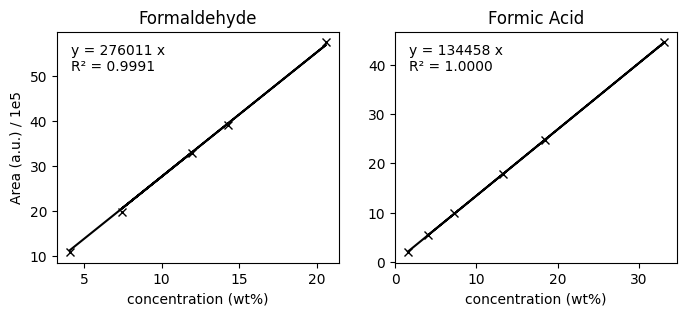

In [59]:
# calculate fit parameters and R² for each calibration series
for dictionary in dictionaries:                                                                                      
    m, residuals, _, _ = np.linalg.lstsq(dictionary['concentrations'].reshape(-1,1), dictionary['areas'])
    slope = m[0]
    dictionary['slope'] = slope                                                                                          
    r2 = R_sq(lambda x: slope*x, dictionary['concentrations'], dictionary['areas'])
    dictionary['r2'] = r2

# plot
fig, (ax1, ax2) = plt.subplots(figsize = (8, 3), ncols = 2)                                 
for dictionary, ax in zip(np.array([FALD, FA]), [ax1, ax2]):                                           
    ax.plot(dictionary['concentrations'], dictionary['areas']/1e5, 'kx')            
    ax.plot(dictionary['concentrations'], dictionary['concentrations']*dictionary['slope']/1e5, 'k-')     
    ax.set_title(dictionary['name'])                                                                
    ax.set_xlabel('concentration (wt%)')                                                            
    eq_text = f"y = {dictionary['slope']:.0f} x\nR² = {dictionary['r2']:.4f}"
    ax.text(0.05, 0.95, eq_text, transform=ax.transAxes, va='top')
ax1.set_ylabel('Area (a.u.) / 1e5')                                                                 
plt.show()

**Chromatogram Extraction**

In [60]:
def extract_chromatogram(filepath):                                         # define function to extract chromatogram data from file
    with open(filepath, 'r', encoding='latin1') as f:                       # open file with correct encoding
        lines = f.readlines()                                               # read all lines into a list

    for i, line in enumerate(lines):
        if line.strip().startswith('[LC Chromatogram(Detector B-Ch1)]'):    # search for the start of the chromatogram data
            data_start = i + 8                                              # skip 8 lines to get to the actual data
            break                                                           # break loop, found start

    data_lines = [] 
    for line in lines[data_start:]:                                         # start reading lines from the data start index
        if not line.strip() or line.strip().startswith('['):                # stop if we reach an empty line or the start of a new section (indicated by '[')
            break
        data_lines.append(line)                                             # otherwise, append line to data lines

    data = np.genfromtxt(data_lines, usecols=(0,1))                         # extract data
    data_export = np.column_stack([60*data[:,0], data[:,1]])                # convert time to seconds and stack with intensity 
    return data_export                                                      # return the data for chromatogram

**Show Example Chromatograms and fit them appropriately**

Tailing is observed for the *Formaldehyde* Samples. To account for that, a exponentially modified gaussian fit can be used as has been performed in works like 

The *Formic Acid* Samples exhibit Fronting. To account for this, a mirrored version of the exponentially modified gaussian is used for fitting

c:\Users\User\Desktop\HPLC-Deconvolution\fit_functions.py:43: RuntimeWarning: overflow encountered in exp
  return prefactor * np.exp(exp_arg) * erfc(erfc_arg)
c:\Users\User\Desktop\HPLC-Deconvolution\fit_functions.py:43: RuntimeWarning: invalid value encountered in multiply
  return prefactor * np.exp(exp_arg) * erfc(erfc_arg)


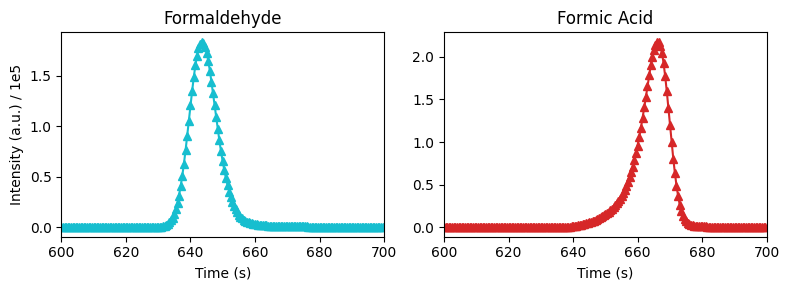

In [61]:
files = ['CAL-FALD-2.txt', 'CAL-FA-3.txt']

# load samples for each calibration (FALD, FA)
idx_1, idx_2 = 1200, 1400  # indices for zoomed-in plot
samples, fits = [], []
for f in files:
    sample = extract_chromatogram(path + f)
    idx_max = np.argmax(sample[:,1])
    i1, i2 = max(0, idx_max - 70), min(len(sample), idx_max + 70)
    x = sample[i1:i2,0]
    y = sample[i1:i2,1]
    if f in FALD['files']:
        popt, _ = sc.optimize.curve_fit(EMG, x, y, p0=FALD['p0'])
        fit = EMG(x, *popt)
    else:
        popt, _ = sc.optimize.curve_fit(EMG_mirrored, x, y, p0=FA['p0'])
        fit = EMG_mirrored(x, *popt)
    samples.append(sample)
    fits.append(np.array([x, fit]).T)

# plot zoomed-in chromatograms
fig, axes = plt.subplots(ncols=2, figsize=(8,3))

for ax, samp, fit, d in zip(axes, samples, fits, dictionaries):
    ax.plot(samp[idx_1:idx_2,0], samp[idx_1:idx_2,1] / 1e5, f'{d["color"]}^')
    ax.plot(fit[:,0], fit[:,1] / 1e5, f'{d["color"]}-')
    ax.set_xlim(samp[idx_1,0], samp[idx_2,0])
    ax.set_title(d['name'])

axes[0].set_ylabel('Intensity (a.u.) / 1e5')
for ax in axes:
    ax.set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

**Determine a Relationship for Sigma and Tau determination for Formaldehyde** 

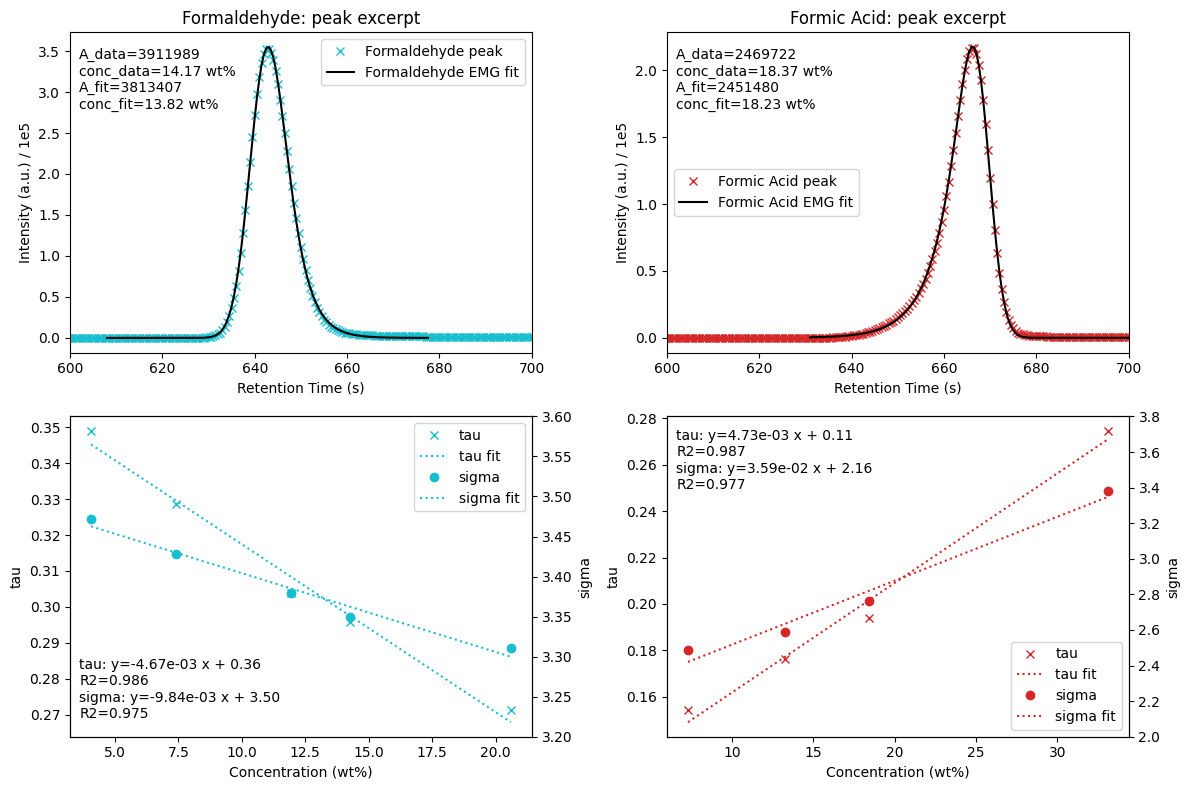

In [62]:
def analyze_calibration(dictionary):
    """Fit the main peak of each trace and collect calibration metrics."""
    model = EMG if dictionary['name'] == 'Formaldehyde' else EMG_mirrored # choose model based on species for tailing and fronting
    for file in dictionary['files']:
        sample = extract_chromatogram(path + file)
        idx_max = np.argmax(sample[:,1])
        i1, i2 = max(0, idx_max - 70), min(len(sample), idx_max + 70)
        x = sample[i1:i2,0]
        y = sample[i1:i2,1]
        popt, _ = sc.optimize.curve_fit(model, x, y, p0=dictionary['p0'])
        h, mu, sigma, tau = popt
        dictionary['hs'].append(h)
        dictionary['mus'].append(mu)
        dictionary['sigmas'].append(sigma)
        dictionary['taus'].append(tau)
        dictionary['fits'].append(np.column_stack((x, model(x, *popt))))
    dictionary['hs'] = np.array(dictionary['hs'])
    dictionary['mus'] = np.array(dictionary['mus'])
    dictionary['sigmas'] = np.array(dictionary['sigmas'])
    dictionary['taus'] = np.array(dictionary['taus'])

analyze_calibration(FALD)
analyze_calibration(FA)

def fit_info(x, y):
    """Return a simple linear calibration fit and its R²."""
    coeffs = np.polyfit(x, y, 1)
    return coeffs, R_sq(np.poly1d(coeffs), x, y)

#Exclude first two points of FA calibration for fitting
FALD_fit_sig = fit_info(FALD['concentrations'], FALD['sigmas'])
FALD_fit_tau = fit_info(FALD['concentrations'], FALD['taus'])

FA_fit_mask = np.argsort(FA['concentrations'])[2:]
FA_fit_sig = fit_info(FA['concentrations'][FA_fit_mask], FA['sigmas'][FA_fit_mask])
FA_fit_tau = fit_info(FA['concentrations'][FA_fit_mask], FA['taus'][FA_fit_mask])

def plot_peak(ax, file):
    """Plot a peak excerpt and overlay the local EMG fit."""
    d = FALD if file in FALD['files'] else FA
    sample = extract_chromatogram(path + file)
    ax.plot(sample[:,0], sample[:,1]/1e5, f'{d['color']}x', label=f'{d['name']} peak')
    ax.plot(d['fits'][d['files'].index(file)][:,0], d['fits'][d['files'].index(file)][:,1]/1e5, 'k-', label=f'{d['name']} EMG fit')
    A_data = d['areas'][d['files'].index(file)]
    A_fit = d['hs'][d['files'].index(file)]
    conc_data = A_data / d['slope']
    conc_fit = A_fit / d['slope']
    ax.text(0.02, 0.95, f'A_data={A_data:.0f}\nconc_data={conc_data:.2f} wt%\nA_fit={A_fit:.0f}\nconc_fit={conc_fit:.2f} wt%', transform=ax.transAxes, va='top')
    ax.set_title(f'{d['name']}: peak excerpt')
    ax.set_xlabel('Retention Time (s)')
    ax.set_ylabel('Intensity (a.u.) / 1e5')
    ax.set_xlim(600, 700)
    ax.legend()

def plot_calibration(ax, dictionary, fit_tau, fit_sig):
    """Plot tau and sigma trends versus concentration."""
    d = dictionary
    if d == FA:
        mask = np.argsort(d['areas'])[2:]
        conc = d['concentrations'][mask]
        sig_arr = d['sigmas'][mask]
        tau_arr = d['taus'][mask]
    else:
        conc, sig_arr, tau_arr = d['concentrations'], d['sigmas'], d['taus']

    ax2 = ax.twinx()
    ax.plot(conc, tau_arr, f'{d["color"]}x', label='tau')
    ax2.plot(conc, sig_arr, f'{d["color"]}o', label='sigma')
    ax2.set_ylim(3.2,3.6) if d == FALD else ax2.set_ylim(2.0, 3.8)

    xs = np.linspace(np.min(conc), np.max(conc), 100)
    coeffs, r2 = fit_tau
    ax.plot(xs, np.poly1d(coeffs)(xs), f'{d["color"]}:', label='tau fit')
    tau_text = f'tau: y={coeffs[0]:.2e} x + {coeffs[1]:.2f}\nR2={r2:.3f}'

    coeffs, r2 = fit_sig
    ax2.plot(xs, np.poly1d(coeffs)(xs), f'{d["color"]}:', label='sigma fit')
    sigma_text = f'sigma: y={coeffs[0]:.2e} x + {coeffs[1]:.2f}\nR2={r2:.3f}'
    if d == FALD:
        ax.text(0.02, 0.05, tau_text + '\n' + sigma_text, transform=ax.transAxes, va='bottom')
    else:
        ax.text(0.02, 0.96, tau_text + '\n' + sigma_text, transform=ax.transAxes, va='top')
    ax.set_xlabel('Concentration (wt%)')
    ax.set_ylabel('tau')
    ax2.set_ylabel('sigma')
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='best')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_peak(axes[0,0], FALD['files'][2])
plot_peak(axes[0,1], FA['files'][2])
plot_calibration(axes[1,0], FALD, FALD_fit_tau, FALD_fit_sig)
plot_calibration(axes[1,1], FA, FA_fit_tau, FA_fit_sig)
fig.tight_layout()
plt.show()

In [63]:
#Tests with preset FALD and FA concentration
FALD_conc, FA_conc = 5.64, 9.53                                                     # wt% of base concentrations
Names = np.array(['FAFALD1', 'FAFALD2', 'FAFALD3', 'FAFALD4', 'FAFALD5', 'FAFALD6'])                      # Names of the mixtures
FALD_mass = np.array([0.4588, 0.9178, 0.6543, 0.5735, 0.4492,0.2454])                              # masses FALD
FA_mass = np.array([0.6864, 0.3066, 0.5077, 0.9715, 0.5593,0.3887]) 
Water_mass = np.array([0, 0, 0, 0, 0.4244,0.6128])                               # masses FA
wt_perc_FALD = FALD_conc*FALD_mass/(FALD_mass+FA_mass+Water_mass)                              # calculation of wt%
wt_perc_FA = FA_conc*FA_mass/(FALD_mass+FA_mass+Water_mass)

col_width = 20
header = f"{'Name':^{col_width}} {'wt% Formaldehyde':^{col_width}} {'wt% Formic Acid':^{col_width}}"
print(header)
print('-' * len(header))
for name, wtFALD, wtFA in zip(Names, wt_perc_FALD, wt_perc_FA):
    print(f"{name:^{col_width}} {wtFALD:^{col_width}.2f} {wtFA:^{col_width}.2f}")

        Name           wt% Formaldehyde     wt% Formic Acid   
--------------------------------------------------------------
      FAFALD1                2.26                 5.71        
      FAFALD2                4.23                 2.39        
      FAFALD3                3.18                 4.16        
      FAFALD4                2.09                 5.99        
      FAFALD5                1.77                 3.72        
      FAFALD6                1.11                 2.97        


Unconstrained fit
===============================TEST-FAFALD-1.txt================================
   Peak        h         mu     sigma     tau    Peak pos.   wt% real   wt% fit  
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 


FileNotFoundError: [Errno 2] No such file or directory: 'data/calibration/TEST-FAFALD-1.txt'

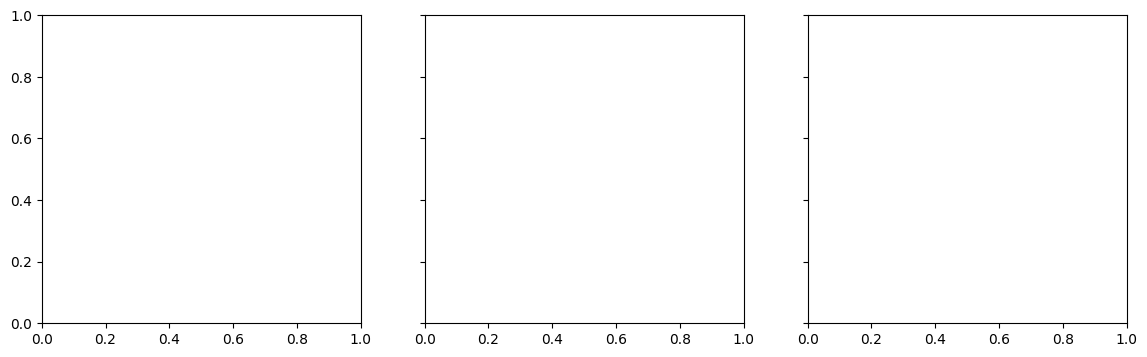

In [64]:
print('Unconstrained fit')
path_1 = 'data/calibration/'
sample_specs = [
    ('TEST-FAFALD-1.txt', wt_perc_FALD[0], wt_perc_FA[0]),
    ('TEST-FAFALD-2.txt', wt_perc_FALD[1], wt_perc_FA[1]),
    ('TEST-FAFALD-5.txt', wt_perc_FALD[4], wt_perc_FA[4]),
]

fig, axes = plt.subplots(ncols=3, figsize=(14, 4), sharey=True)

for ax, (sample_file, wt_fald_real, wt_fa_real) in zip(axes, sample_specs):
    print(sample_file.center(80, '='))
    print(f"{'Peak':^10} {'h':^10} {'mu':^8} {'sigma':^8} {'tau':^8} {'Peak pos.':^10} {'wt% real':^10} {'wt% fit':^10}")
    print('- ' * 40)

    sample = extract_chromatogram(path_1 + sample_file)
    index_1 = max(0, np.argmax(sample[:,1]) - 70)
    index_2 = min(len(sample), np.argmax(sample[:,1]) + 70)

    initial_guess = [1e5, 644, 3.625, 0.33, 1e4, 660, 2.665, 0.1634]
    lower_bounds = [0, 640, 0, 0, 0, 658, 0, 0]
    upper_bounds = [np.inf, 645, 4, 0.7, np.inf, 666, 3, 0.3]
    popt, _ = sc.optimize.curve_fit(EMGsTailFront, sample[index_1:index_2,0], sample[index_1:index_2,1],
                                    p0=initial_guess, bounds=[lower_bounds, upper_bounds])
    h1, mu1, sigma1, tau1 = popt[:4]
    h2, mu2, sigma2, tau2 = popt[4:]

    #calculate fit functions
    EMG_FALD = EMG(sample[index_1:index_2,0], h1, mu1, sigma1, tau1)
    EMG_FA = EMG_mirrored(sample[index_1:index_2,0], h2, mu2, sigma2, tau2)

    print(f"{'FALD':^10} {h1:^10.0f} {mu1:^8.1f} {sigma1:^8.3f} {tau1:^8.3f} {sample[index_1:index_2,0][np.argmax(EMG_FALD)]:^10.1f} {wt_fald_real:^10.2f} {h1/FALD['slope']:^10.2f}")
    print(f"{'FA':^10} {h2:^10.0f} {mu2:^8.1f} {sigma2:^8.3f} {tau2:^8.3f} {sample[index_1:index_2,0][np.argmax(EMG_FA)]:^10.1f} {wt_fa_real:^10.2f} {h2/FA['slope']:^10.2f}")
    print()
    #plot
    ax.plot(sample[:,0], sample[:,1] / 1e5, 'C0o')
    ax.plot(sample[index_1:index_2,0], EMG_FALD / 1e5, 'k:')
    ax.plot(sample[index_1:index_2,0], EMG_FA / 1e5, 'k--')
    ax.plot(sample[index_1:index_2,0], (EMG_FALD + EMG_FA) / 1e5, 'k-', lw=5)
    ax.set_xlim(600, 700)
    ax.set_title(sample_file.replace('.txt', ''))
    ax.set_xlabel('Retention Time (s)')
    ax.legend(['Data', 'FALD fit', 'FA fit', 'Sum fit'])

axes[0].set_ylabel('Intensity (a.u.) / 1e5')
fig.tight_layout()
plt.show()

Constrained fit - only sigma
===============================TEST-FAFALD-1.txt================================
   Peak        h         mu     sigma     tau    Peak pos.   wt% real   wt% fit  
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 


c:\Users\User\Desktop\HPLC-Deconvolution\fit_functions.py:112: RuntimeWarning: overflow encountered in exp
  return prefactor * np.exp(exp_arg) * erfc(erfc_arg)
c:\Users\User\Desktop\HPLC-Deconvolution\fit_functions.py:112: RuntimeWarning: invalid value encountered in multiply
  return prefactor * np.exp(exp_arg) * erfc(erfc_arg)


ValueError: Residuals are not finite in the initial point.

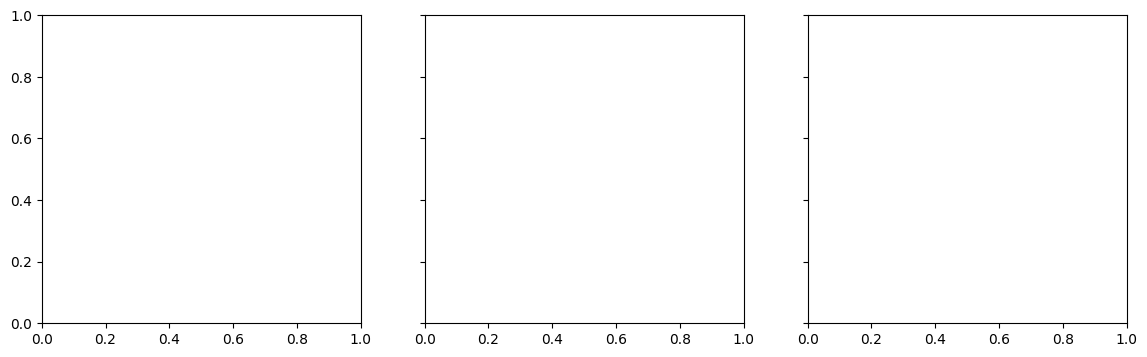

In [ ]:
#Constrained fit - only sigma
print('Constrained fit - only sigma')
path_1 = 'data/'
sample_specs = [
    ('TEST-FAFALD-1.txt', wt_perc_FALD[0], wt_perc_FA[0]),
    ('TEST-FAFALD-2.txt', wt_perc_FALD[1], wt_perc_FA[1]),
    ('TEST-FAFALD-5.txt', wt_perc_FALD[4], wt_perc_FA[4]),
]

# Use factory functions from fit_functions to avoid local duplicates
# Create sigma-constrained EMG functions using the calibration fit coefficients
constrained_EMG = make_sigma_constrained_EMG(FALD_fit_sig[0])
constrained_EMG_mirrored = make_sigma_constrained_EMG_mirrored(FA_fit_sig[0])
constrained_EMGsTailFront = make_sigma_constrained_EMGsTailFront(FALD_fit_sig[0], FA_fit_sig[0])

fig, axes = plt.subplots(ncols=3, figsize=(14, 4), sharey=True)
s = lambda value: float(np.ravel(value)[0])

for ax, (sample_file, wt_FALD_real, wt_fa_real) in zip(axes, sample_specs):
    print(sample_file.center(80, '='))
    print(f"{'Peak':^10} {'h':^10} {'mu':^8} {'sigma':^8} {'tau':^8} {'Peak pos.':^10} {'wt% real':^10} {'wt% fit':^10}")
    print('- ' * 40)

    sample = extract_chromatogram(path_1 + sample_file)
    index_1 = max(0, np.argmax(sample[:,1]) - 70)
    index_2 = min(len(sample), np.argmax(sample[:,1]) + 70)

    initial_guess = [8e5, 644, 0.35, 1e4, 660, 0.13]
    lower_bounds = [0, 640, 0, 0, 660, 0]
    upper_bounds = [np.inf, 650, 0.5, np.inf, 666, 0.5]
    popt, _ = sc.optimize.curve_fit(constrained_EMGsTailFront, sample[index_1:index_2,0], sample[index_1:index_2,1],
                                    p0=initial_guess, bounds=[lower_bounds, upper_bounds])
    h1, mu1, tau1 = popt[:3]
    sigma1 = FALD_fit_sig[1] + h1 * FALD_fit_sig[0]
    h2, mu2, tau2 = popt[3:]
    sigma2 = FA_fit_sig[1] + h2 * FA_fit_sig[0]

    #calculate fit functions
    EMG_FALD = constrained_EMG(sample[index_1:index_2,0], h1, mu1, tau1)
    EMG_FA = constrained_EMG_mirrored(sample[index_1:index_2,0], h2, mu2, tau2)

    print(f"{'FALD':^10} {s(h1):^10.0f} {s(mu1):^8.1f} {s(sigma1):^8.3f} {s(tau1):^8.3f} {s(sample[index_1:index_2,0][np.argmax(EMG_FALD)]):^10.1f} {wt_FALD_real:^10.2f} {s(h1/FALD['slope']):^10.2f}")
    print(f"{'FA':^10} {s(h2):^10.0f} {s(mu2):^8.1f} {s(sigma2):^8.3f} {s(tau2):^8.3f} {s(sample[index_1:index_2,0][np.argmax(EMG_FA)]):^10.1f} {wt_fa_real:^10.2f} {s(h2/FA['slope']):^10.2f}")
    print()

    #plot
    ax.plot(sample[:,0], sample[:,1] / 1e5, 'C0o')
    ax.plot(sample[index_1:index_2,0], EMG_FALD / 1e5, 'k:')
    ax.plot(sample[index_1:index_2,0], EMG_FA / 1e5, 'k--')
    ax.plot(sample[index_1:index_2,0], (EMG_FALD + EMG_FA) / 1e5, 'k-', lw=5)
    ax.set_xlim(600, 700)
    ax.set_title(sample_file.replace('.txt', ''))
    ax.set_xlabel('Retention Time (s)')
    ax.legend(['Data', 'FALD fit', 'FA fit', 'Sum fit'])

axes[0].set_ylabel('Intensity (a.u.) / 1e5')
fig.tight_layout()
plt.show()

Constrained fit - only tau
===============================TEST-FAFALD-1.txt================================
   Peak        h         mu     sigma     tau    Peak pos.   wt% real   wt% fit  
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
   FALD      520049    641.4    2.500    0.355     643.5       2.26       1.88   
    FA       848579    664.2    2.500    0.143     661.5       5.71       6.31   

===============================TEST-FAFALD-2.txt================================
   Peak        h         mu     sigma     tau    Peak pos.   wt% real   wt% fit  
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
   FALD      969004    641.3    2.500    0.347     643.0       4.23       3.51   
    FA       461265    660.0    2.500    0.130     657.0       2.39       3.43   

===============================TEST-FAFALD-5.txt================================
   Peak        h         mu     sigma     tau    Peak pos.   wt% real   wt

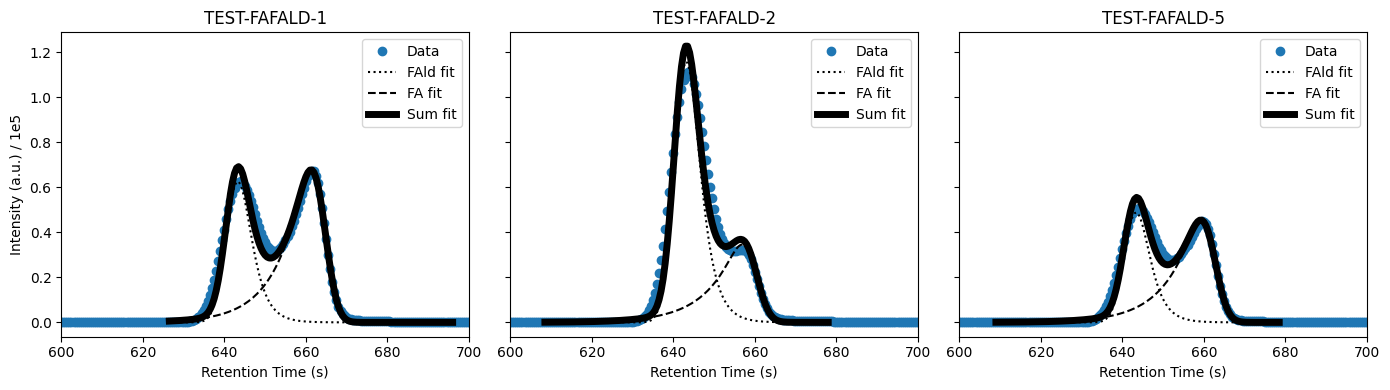

In [ ]:
# Constrained fit - only tau
print('Constrained fit - only tau')
path_1 = 'data/calibration/'
sample_specs = [
    ('TEST-FAFALD-1.txt', wt_perc_FALD[0], wt_perc_FA[0]),
    ('TEST-FAFALD-2.txt', wt_perc_FALD[1], wt_perc_FA[1]),
    ('TEST-FAFALD-5.txt', wt_perc_FALD[4], wt_perc_FA[4]),
]

# Build tau-constrained models from linear calibration fits
FALD_tau_coeffs = FALD_fit_tau[0]
FA_tau_coeffs = FA_fit_tau[0]

def tau_constrained_EMG(x, h, mu, sigma):
    tau = FALD_tau_coeffs[1] + h * FALD_tau_coeffs[0]
    return EMG(x, h, mu, sigma, tau)

def tau_constrained_EMG_mirrored(x, h, mu, sigma):
    tau = FA_tau_coeffs[1] + h * FA_tau_coeffs[0]
    return EMG_mirrored(x, h, mu, sigma, tau)

def tau_constrained_EMGsTailFront(x, h1, mu1, sigma1, h2, mu2, sigma2):
    return tau_constrained_EMG(x, h1, mu1, sigma1) + tau_constrained_EMG_mirrored(x, h2, mu2, sigma2)

fig, axes = plt.subplots(ncols=3, figsize=(14, 4), sharey=True)
s = lambda value: float(np.ravel(value)[0])

for ax, (sample_file, wt_FALD_real, wt_fa_real) in zip(axes, sample_specs):
    print(sample_file.center(80, '='))
    print(f"{'Peak':^10} {'h':^10} {'mu':^8} {'sigma':^8} {'tau':^8} {'Peak pos.':^10} {'wt% real':^10} {'wt% fit':^10}")
    print('- ' * 40)

    sample = extract_chromatogram(path_1 + sample_file)
    index_1 = max(0, np.argmax(sample[:,1]) - 70)
    index_2 = min(len(sample), np.argmax(sample[:,1]) + 70)

    initial_guess = [8e5, 644, 0.95, 1e4, 660, 1.10]
    lower_bounds = [0, 640, 0, 0, 660, 0]
    upper_bounds = [np.inf, 650, 2.5, np.inf, 666, 2.5]
    popt, _ = sc.optimize.curve_fit(
        tau_constrained_EMGsTailFront,
        sample[index_1:index_2,0],
        sample[index_1:index_2,1],
        p0=initial_guess,
        bounds=[lower_bounds, upper_bounds],
    )

    h1, mu1, sigma1 = popt[:3]
    tau1 = FALD_tau_coeffs[1] + h1 * FALD_tau_coeffs[0]
    h2, mu2, sigma2 = popt[3:]
    tau2 = FA_tau_coeffs[1] + h2 * FA_tau_coeffs[0]

    EMG_FALD = tau_constrained_EMG(sample[index_1:index_2,0], h1, mu1, sigma1)
    EMG_FA = tau_constrained_EMG_mirrored(sample[index_1:index_2,0], h2, mu2, sigma2)

    print(f"{'FALD':^10} {s(h1):^10.0f} {s(mu1):^8.1f} {s(sigma1):^8.3f} {s(tau1):^8.3f} {s(sample[index_1:index_2,0][np.argmax(EMG_FALD)]):^10.1f} {wt_FALD_real:^10.2f} {s(h1/FALD['slope']):^10.2f}")
    print(f"{'FA':^10} {s(h2):^10.0f} {s(mu2):^8.1f} {s(sigma2):^8.3f} {s(tau2):^8.3f} {s(sample[index_1:index_2,0][np.argmax(EMG_FA)]):^10.1f} {wt_fa_real:^10.2f} {s(h2/FA['slope']):^10.2f}")
    print()

    ax.plot(sample[:,0], sample[:,1] / 1e5, 'C0o')
    ax.plot(sample[index_1:index_2,0], EMG_FALD / 1e5, 'k:')
    ax.plot(sample[index_1:index_2,0], EMG_FA / 1e5, 'k--')
    ax.plot(sample[index_1:index_2,0], (EMG_FALD + EMG_FA) / 1e5, 'k-', lw=5)
    ax.set_xlim(600, 700)
    ax.set_title(sample_file.replace('.txt', ''))
    ax.set_xlabel('Retention Time (s)')
    ax.legend(['Data', 'FALD fit', 'FA fit', 'Sum fit'])

axes[0].set_ylabel('Intensity (a.u.) / 1e5')
fig.tight_layout()
plt.show()

In [ ]:
#import chromatogram
print('Constrained fit')
print('-'*80)
path_35 = 'data/calibration/'
files_35 = sorted(glob.glob(path_35 + 'CAL-*.txt'))

path_35_2 = 'data/calibration/'
files_35_2 = sorted(glob.glob(path_35_2 + 'TEST-FAFALD-*.txt'))

# Use factory functions from fit_functions to build constrained models
constrained_EMG = make_constrained_EMG(FALD_coeffs_tau, FALD_coeffs_wid)
constrained_EMG_mirrored = make_constrained_EMG_mirrored(FA_coeffs_tau, FA_coeffs_wid)
constrained_EMGsTailFront = make_constrained_EMGsTailFront(
    FALD_coeffs_tau,
    FALD_coeffs_wid,
    FA_coeffs_tau,
    FA_coeffs_wid,
 )

initial_guess = [1e7, 644, 1e5, 658]                                                                                    # define initial guesses and bounds
lower_bounds = [1, 630, 1, 656]
upper_bounds = [np.inf, 645, np.inf, 665]

popt, _ = sc.optimize.curve_fit(constrained_EMGsTailFront, sample[index_1:index_2,0], sample[index_1:index_2,1],        # calculate popt
                                p0 = initial_guess, bounds = [lower_bounds, upper_bounds])

h1, mu1 = popt[:2]                                                                                                      # calculate sigma and tau
sigma1 = FALD_coeffs_wid[1]+h1*FALD_coeffs_wid[0]
tau1 = FALD_coeffs_tau[1]+h1*FALD_coeffs_tau[0]
h2, mu2 = popt[2:]
sigma2 = FA_coeffs_wid[1]+h2*FA_coeffs_wid[0]
tau2 = FA_coeffs_tau[1]+h2*FA_coeffs_tau[0]

EMG_FALD = constrained_EMG(sample[index_1:index_2,0], h1, mu1)                                                          # calculate fit functions
EMG_FA   = constrained_EMG_mirrored(sample[index_1:index_2,0], h2, mu2)

print(f"{'Peak':<10} {'h':<12} {'mu':<10} {'sigma':<10} {'tau':<10} {'[wt%]':<12} {'Peak pos.':<12}")                   #print Peak pos and popt
print("-" * 80)
print(f"{'FALD':<10} {h1:<12.2f} {mu1:<10.3f} {sigma1:<10.3f} {tau1:<10.3f} {h1/FALD['slope']:<12.2f} {sample[index_1:index_2,0][np.argmax(EMG_FALD)]:<12.2f}")
print(f"{'FA':<10} {h2:<12.2f} {mu2:<10.3f} {sigma2:<10.3f} {tau2:<10.3f} {h2/FA['slope']:<12.2f} {sample[index_1:index_2,0][np.argmax(EMG_FA)]:<12.2f}")

fig, ax = plt.subplots(figsize = (4,2.5))                                                                                #plot
ax.plot(sample[:,0], sample[:,1], 'C0o', label='Data')
ax.plot(sample[index_1:index_2,0], EMG_FALD, 'k:', label='FALD fit')
ax.plot(sample[index_1:index_2,0], EMG_FA, 'k--', label='FA fit')
ax.plot(sample[index_1:index_2,0], EMG_FALD+EMG_FA, 'k-', lw = 5, label='Sum fit')
ax.set_xlim(600, 700)
ax.set_xlabel('Retention Time (s)')
ax.set_ylabel('Intensity (a.u.)')
ax.legend()
plt.show()

Constrained fit
--------------------------------------------------------------------------------


NameError: name 'FAld_coeffs_tau' is not defined